### Библиотеки

In [1]:
import numpy as np
import math as math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### Pandas

In [2]:
# У нас есть структура в Pandas DataFrame - df

df = pd.DataFrame({
    'name': ['Ivan','Masha','Oleg'],
    'age': [20,25,30],
    'salary': [20000,30000,50000]
})

print(df)

    name  age  salary
0   Ivan   20   20000
1  Masha   25   30000
2   Oleg   30   50000


In [7]:
df = pd.read_excel("Trading_stats_2026.xlsx")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Номер сделки                  50 non-null     int64         
 1   Риск                          50 non-null     int64         
 2   Тейк                          50 non-null     int64         
 3   Тейк/Риск                     49 non-null     float64       
 4   Итоговый Pnl%                 49 non-null     float64       
 5   Тип сделки(short/long)        49 non-null     object        
 6   Какой принцип входа в сделку  49 non-null     object        
 7   Валютная пара                 49 non-null     object        
 8   Время входа                   49 non-null     object        
 9   Время выхода                  49 non-null     object        
 10  Исход сделки                  49 non-null     float64       
 11  Дата                          49 n

In [23]:
df[['Номер сделки',
    'Тейк/Риск',
    'Тип сделки(short/long)',
    'Исход сделки']]


,Номер сделки,Тейк/Риск,Тип сделки(short/long),Исход сделки
0,1,4.080000,short,0.16
1,2,0.645000,long,0.13
2,3,1.362500,short,0.28
3,4,0.772201,short,-0.08
4,5,2.495000,short,0.53
5,6,0.615000,short,0.24
6,7,1.152500,short,0.46
7,8,3.857500,long,1.65
8,9,3.950000,long,1.91
9,10,0.177500,short,0.09


In [24]:
df.loc[df['Номер сделки']<10,['Номер сделки',
    'Тейк/Риск',
    'Тип сделки(short/long)',
    'Исход сделки']]

,Номер сделки,Тейк/Риск,Тип сделки(short/long),Исход сделки
0,1,4.080000,short,0.16
1,2,0.645000,long,0.13
2,3,1.362500,short,0.28
3,4,0.772201,short,-0.08
4,5,2.495000,short,0.53
5,6,0.615000,short,0.24
6,7,1.152500,short,0.46
7,8,3.857500,long,1.65
8,9,3.950000,long,1.91


### ГРАФИКИ

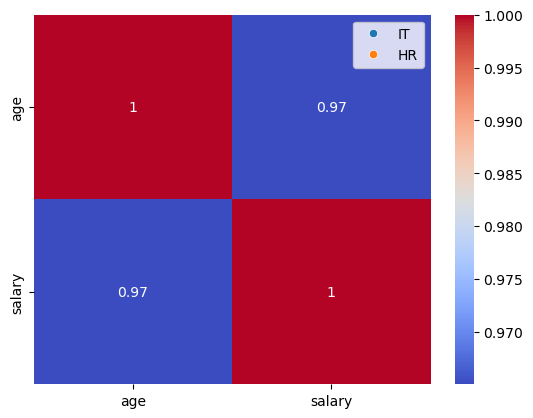

In [33]:
df = pd.DataFrame({
    "age":    [25, 30, 22, 35, 28],
    "salary": [50000, 80000, 45000, 90000, 60000],
    "dept":   ["IT", "HR", "IT", "HR", "IT"]
})

# Scatter с группировкой по цвету
sns.scatterplot(data=df, x="age", y="salary", hue="dept")

# Гистограмма с кривой плотности
sns.histplot(df["salary"], kde=True)

# Boxplot — распределение по группам
sns.boxplot(data=df, x="dept", y="salary")

# Heatmap — корреляция между признаками (очень часто в ML!)
corr = df[["age", "salary"]].corr()  # матрица корреляций
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

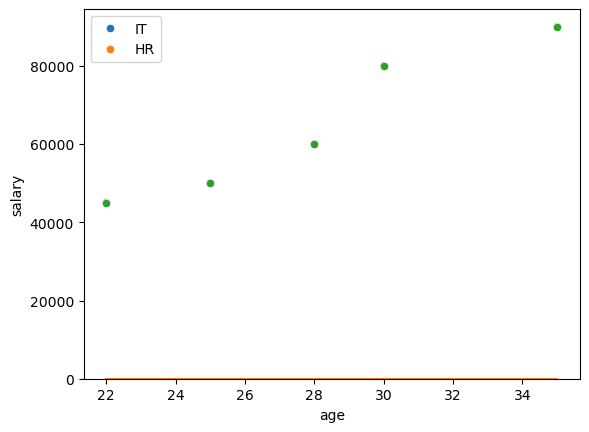

In [35]:
sns.scatterplot(data=df, x="age", y="salary", hue="dept")

# 1. Посмотреть распределение признака
sns.histplot(df["age"], kde=True)

# 2. Посмотреть связь между признаками
sns.scatterplot(data=df, x="age", y="salary")

# 3. Корреляционная матрица перед обучением модели

plt.show()


### Реальный датасет на предикт цены дома

In [2]:
# читка данных

df = pd.read_csv('train.csv')

In [10]:
print('shape = ',df.shape)

shape =  (1460, 81)


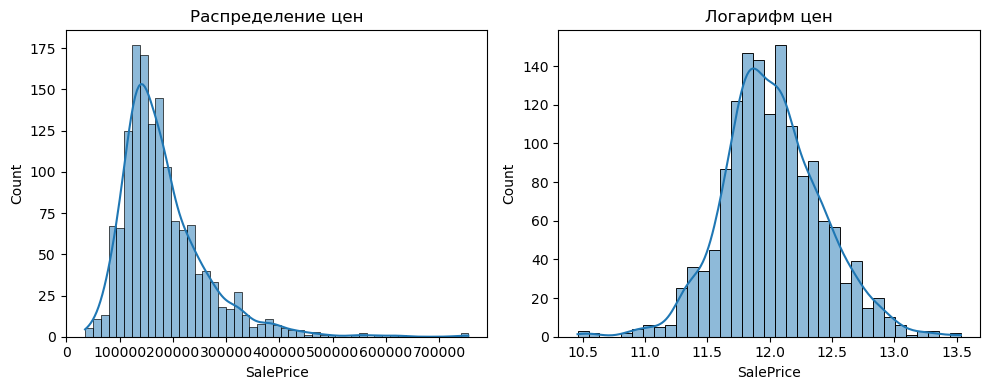

In [12]:
# SalePrice — то что мы хотим предсказать
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["SalePrice"], kde=True)
plt.title("Распределение цен")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df["SalePrice"]), kde=True)  # log трансформация
plt.title("Логарифм цен")

plt.tight_layout()
plt.show()

# В регрессии часто логарифмируют цену — распределение становится нормальным
# log1p(x) = log(x + 1) — чтобы избежать log(0)

In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


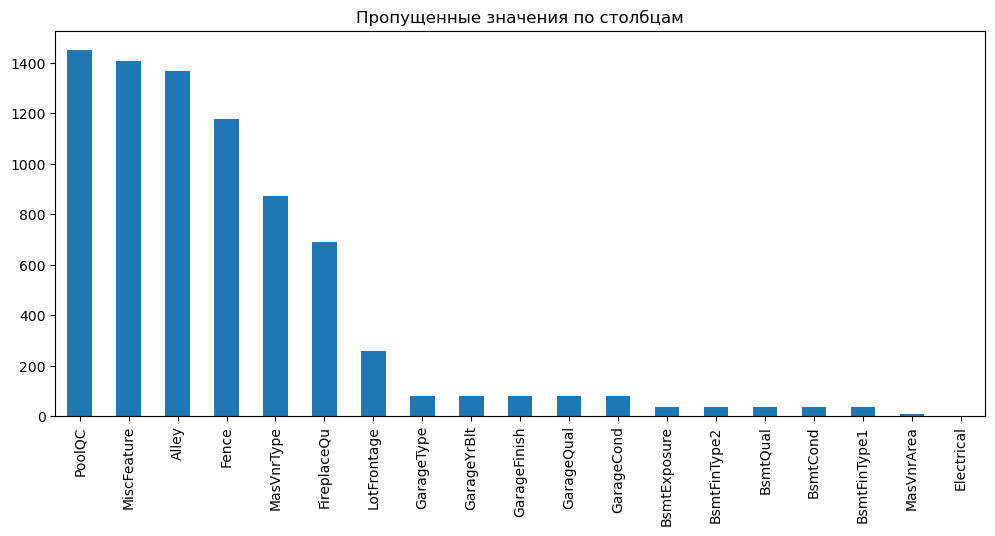

In [15]:
plt.figure(figsize=(12,5))
missing.plot(kind='bar')
plt.title('Пропущенные значения по столбцам')
plt.show()

In [17]:
corr = df.select_dtypes(include=[np.number]).corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(11))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


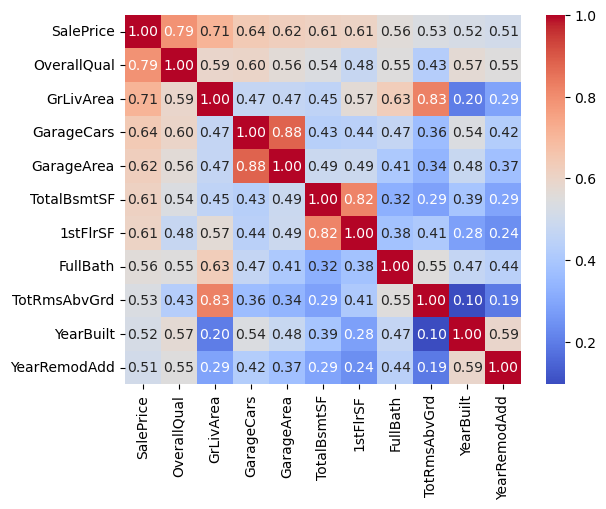

In [19]:
top_features = corr.head(11).index
sns.heatmap(df[top_features].corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

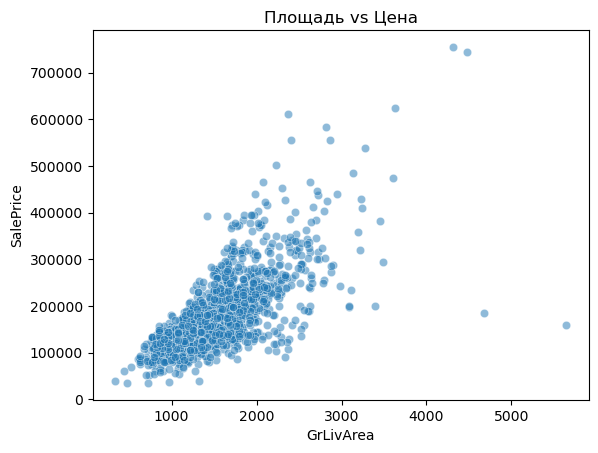

In [22]:
sns.scatterplot(data=df,x='GrLivArea',y='SalePrice',alpha=0.5)
plt.title('Площадь vs Цена')
plt.show()

In [23]:
nummeric_df = df.select_dtypes(include=[np.number])
nummeric_df = nummeric_df.fillna(nummeric_df.median())

X = nummeric_df.drop(columns = ['SalePrice','Id'])
y=np.log1p(df['SalePrice'])

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)# выбор данных для обучения
model = LinearRegression() ## выбор модели

model.fit(X_train,y_train) # вставляем данные для обучения

y_pred = model.predict(X_test)# модель пытается предугадать

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print(f'RMSE: {rmse:.4f}')
print(model.score(X_test,y_test))

RMSE: 0.1519
0.8764130909815004


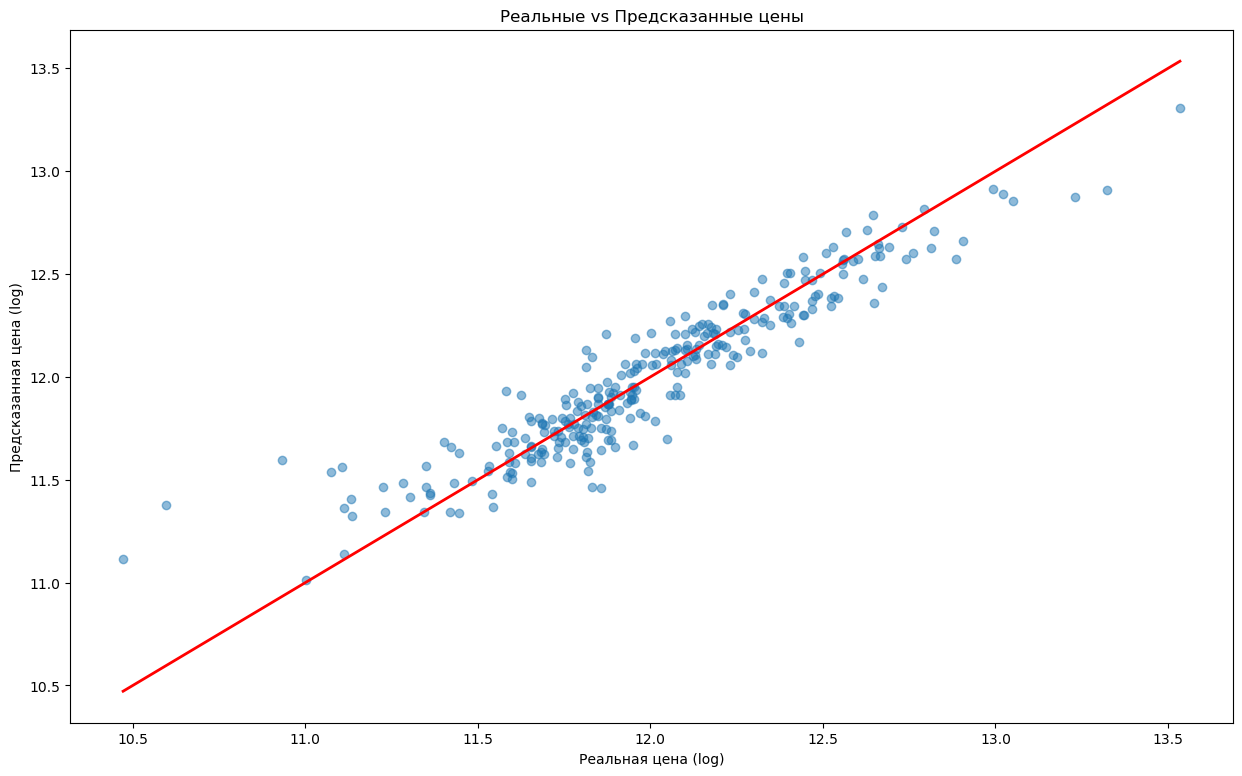

In [28]:
plt.figure(figsize = (15,9))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color='red',linewidth=2)
plt.xlabel("Реальная цена (log)")
plt.ylabel("Предсказанная цена (log)")
plt.title("Реальные vs Предсказанные цены")
plt.show()

### Обучние scikit-learn

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [33]:
# Все работают одинаково!
models = {
    "Linear":   LinearRegression(),
    "Ridge":    Ridge(alpha=1.0),        # линейная с L2 регуляризацией
    "Lasso":    Lasso(alpha=0.001),      # линейная с L1 регуляризацией
    "Tree":     DecisionTreeRegressor(max_depth=5),
    "Forest":   RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# Сравниваем все модели сразу
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name:10} RMSE: {rmse:.4f}")

Linear     RMSE: 0.1519
Ridge      RMSE: 0.1518
Lasso      RMSE: 0.1521
Tree       RMSE: 0.2046
Forest     RMSE: 0.1487
Gradient   RMSE: 0.1428


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # считает mean/std и трансформирует
X_test_scaled  = scaler.transform(X_test)        # использует mean/std из train!

# Важно: fit_transform только на train, на test только transform
# Иначе будет "утечка данных" (data leakage) — частая ошибка новичков

In [35]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge(alpha=1.0))
])

pipe.fit(X_train, y_train)    # автоматически нормализует и обучает
pipe.predict(X_test)          # автоматически нормализует и предсказывает

array([11.95034633, 12.62967496, 11.66258433, 12.06110965, 12.62509516,
       11.34474664, 12.35964441, 11.92060397, 11.34466775, 11.86808796,
       11.90080902, 11.71012042, 11.41933799, 12.17695042, 12.13357212,
       11.812813  , 12.23479384, 11.77034662, 11.63278927, 12.28441611,
       12.03098483, 12.22806033, 12.12406168, 11.8022545 , 12.21528963,
       11.88697857, 12.15352313, 11.46205464, 12.07872804, 12.0985384 ,
       11.68376471, 12.4988057 , 12.15394024, 11.540905  , 12.51500551,
       11.9478822 , 11.82675501, 12.28294548, 12.78567824, 11.49476912,
       11.80368892, 12.40039956, 11.62490144, 12.58285935, 11.75854135,
       11.62646666, 11.59050459, 11.78698224, 12.88745039, 11.6916241 ,
       11.64836391, 12.20873208, 11.65925257, 12.70171035, 11.92546067,
       12.36899017, 12.30968128, 11.91304544, 11.92916161, 11.68303404,
       11.32315221, 11.89318365, 12.58703113, 12.40270812, 12.54631736,
       12.30311859, 11.53324816, 12.71234347, 11.6299143 , 11.95

In [36]:
from sklearn.model_selection import cross_val_score

model = RandomForestRegressor(n_estimators=100, random_state=42)

# cv=5 — делит данные на 5 частей, обучает 5 раз
scores = cross_val_score(model, X, y, cv=5, scoring="neg_root_mean_squared_error")
rmse_scores = -scores  # возвращает отрицательные значения, поэтому меняем знак

print(f"RMSE по фолдам: {rmse_scores}")
print(f"Среднее RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

RMSE по фолдам: [0.14469378 0.15891166 0.14834882 0.13283231 0.15410902]
Среднее RMSE: 0.1478 ± 0.0089


In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth":    [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1   # использовать все ядра процессора
)

grid.fit(X_train, y_train)
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший RMSE: {-grid.best_score_:.4f}")

Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Лучший RMSE: 0.1457


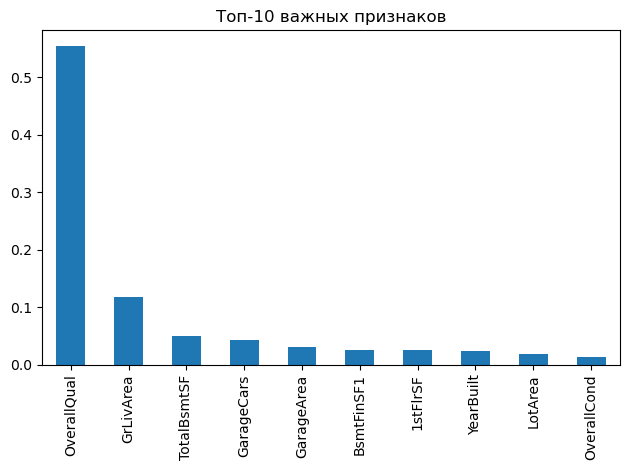

In [38]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Важность признаков
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Топ-10 важных признаков")
plt.tight_layout()
plt.show()

In [56]:
models = {
    "Gradient": GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBRegressor': XGBRegressor(
                                    n_estimators=1000,
                                    learning_rate=0.05,
                                    max_depth=6,
                                    random_state=42,
                                    n_jobs=-1
                                )
}
param_grid = {
    "n_estimators": [50, 100, 200,1000],
    "max_depth":    [5, 10, None],
    "min_samples_split": [2, 5]
}

# Сравниваем все модели сразу
results = {}
for name, model in models.items():

    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1   # использовать все ядра процессора
    )
    
    grid.fit(X_train, y_train)
    results[name] = (-grid.best_score_,grid.best_params_)
    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Лучший RMSE: {-grid.best_score_:.4f}")

Лучшие параметры: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 1000}
Лучший RMSE: 0.1372


c:\Users\polon\anaconda3\envs\ml_trading\lib\site-packages\xgboost\training.py:200: UserWarning: [19:42:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Лучшие параметры: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Лучший RMSE: 0.1384


In [57]:
best_key =min(results,key=lambda x:results[x][0]) 
print(best_key,results[best_key])

Gradient (np.float64(0.1372217398340771), {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 1000})


In [58]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=100)   # показывает прогресс каждые 100 итераций

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"XGBoost RMSE: {rmse:.4f}")

[0]	validation_0-rmse:0.41681
[100]	validation_0-rmse:0.14714
[200]	validation_0-rmse:0.14655
[300]	validation_0-rmse:0.14676
[400]	validation_0-rmse:0.14749
[500]	validation_0-rmse:0.14791
[600]	validation_0-rmse:0.14782
[700]	validation_0-rmse:0.14798
[800]	validation_0-rmse:0.14801
[900]	validation_0-rmse:0.14804
[999]	validation_0-rmse:0.14806
XGBoost RMSE: 0.1481
